In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from imblearn.over_sampling import KMeansSMOTE
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,StackingClassifier ,IsolationForest,  AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,cohen_kappa_score, classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance


In [2]:
df = pd.read_csv("Debernardi et al 2020 data.csv")
df.shape

(590, 14)

In [3]:
df.head()


,sample_id,patient_cohort,sample_origin,age,sex,diagnosis,stage,benign_sample_diagnosis,plasma_CA19_9,creatinine,LYVE1,REG1B,TFF1,REG1A
0,S1,Cohort1,BPTB,33,F,1,NaN,NaN,11.7,1.83222,0.893219,52.94884,654.282174,1262.000
1,S10,Cohort1,BPTB,81,F,1,NaN,NaN,NaN,0.97266,2.037585,94.46703,209.488250,228.407
2,S100,Cohort2,BPTB,51,M,1,NaN,NaN,7.0,0.78039,0.145589,102.36600,461.141000,NaN
3,S101,Cohort2,BPTB,61,M,1,NaN,NaN,8.0,0.70122,0.002805,60.57900,142.950000,NaN
4,S102,Cohort2,BPTB,62,M,1,NaN,NaN,9.0,0.21489,0.000860,65.54000,41.088000,NaN


In [4]:
df.describe




<bound method NDFrame.describe of     sample_id patient_cohort sample_origin  age sex  diagnosis stage  \
0          S1        Cohort1          BPTB   33   F          1   NaN   
1         S10        Cohort1          BPTB   81   F          1   NaN   
2        S100        Cohort2          BPTB   51   M          1   NaN   
3        S101        Cohort2          BPTB   61   M          1   NaN   
4        S102        Cohort2          BPTB   62   M          1   NaN   
..        ...            ...           ...  ...  ..        ...   ...   
585      S549        Cohort2          BPTB   68   M          3    IV   
586      S558        Cohort2          BPTB   71   F          3    IV   
587      S560        Cohort2          BPTB   63   M          3    IV   
588      S583        Cohort2          BPTB   75   F          3    IV   
589      S590        Cohort1          BPTB   74   M          3    IV   

    benign_sample_diagnosis  plasma_CA19_9  creatinine     LYVE1       REG1B  \
0                    

In [5]:
columns_ = df.columns.to_list()

df = df [["stage",
          "creatinine",
           "plasma_CA19_9",
          "age",
          "sex",
          "LYVE1",
          "REG1B",
          "TFF1",
          "REG1A",
          "diagnosis"]].copy()
df.sex =df.sex.map({"M":1 , "F": 0})
df.head()

,stage,creatinine,plasma_CA19_9,age,sex,LYVE1,REG1B,TFF1,REG1A,diagnosis
0,NaN,1.83222,11.7,33,0,0.893219,52.94884,654.282174,1262.000,1
1,NaN,0.97266,NaN,81,0,2.037585,94.46703,209.488250,228.407,1
2,NaN,0.78039,7.0,51,1,0.145589,102.36600,461.141000,NaN,1
3,NaN,0.70122,8.0,61,1,0.002805,60.57900,142.950000,NaN,1
4,NaN,0.21489,9.0,62,1,0.000860,65.54000,41.088000,NaN,1


In [6]:
df.isna().sum()


stage            391
creatinine         0
plasma_CA19_9    240
age                0
sex                0
LYVE1              0
REG1B              0
TFF1               0
REG1A            284
diagnosis          0
dtype: int64

In [7]:
#encoding
df['stage'] = df['stage'].fillna('Unknown')

# Step 2: Map the values
df['stage'] = df['stage'].map({
    'I': 1,
    'IA': 1,
    'IB': 1,
    'II': 2,
    'IIA': 2,
    'IIB': 2,
    'III': 3,
    'IV': 4,
    'Unknown': 0  
})


df['stage'] = df['stage'].astype(int)
print(df['stage'].unique())

[0 1 2 3 4]


In [8]:

from tabulate import tabulate

# List of feature columns
features = ['stage', 'creatinine', 'plasma_CA19_9', 'age', 'sex', 'LYVE1', 'REG1B', 'TFF1', 'REG1A']

for index, feature in enumerate(features):
    print(f"Index: {index}, Feature: {feature}")
# Group by diagnosis type
grouped = df.groupby('diagnosis')

# Calculate min, max, and mean for each feature within each diagnosis category
stats = grouped[features].agg(['min', 'max', 'mean'])

# Flatten MultiIndex columns
stats.columns = ['_'.join(col).strip() for col in stats.columns.values]

# Reset index to turn 'diagnosis' back into a column
stats = stats.reset_index()

# Set 'diagnosis' as index to prepare for transpose
stats = stats.set_index('diagnosis')

# Transpose rows and columns
stats_t = stats.transpose()

# To make the output clearer, optionally reset index or rename columns
# For display, you might want to set 'diagnosis' as the header row
# and have features as rows, stats as columns

# Print the transposed table
print(tabulate(stats_t, headers='keys', tablefmt='grid'))

Index: 0, Feature: stage
Index: 1, Feature: creatinine
Index: 2, Feature: plasma_CA19_9
Index: 3, Feature: age
Index: 4, Feature: sex
Index: 5, Feature: LYVE1
Index: 6, Feature: REG1B
Index: 7, Feature: TFF1
Index: 8, Feature: REG1A
+--------------------+---------------+---------------+----------------+
|                    |             1 |             2 |              3 |
+====================+===============+===============+================+
| stage_min          |    0          |    0          |     1          |
+--------------------+---------------+---------------+----------------+
| stage_max          |    0          |    0          |     4          |
+--------------------+---------------+---------------+----------------+
| stage_mean         |    0          |    0          |     2.51256    |
+--------------------+---------------+---------------+----------------+
| creatinine_min     |    0.06786    |    0.05655    |     0.07917    |
+--------------------+---------------+---------

In [9]:
mean_plasma_diagnosis_1 = df.loc[df['diagnosis'] == 1, 'plasma_CA19_9'].mean()
mean_plasma_diagnosis_2 = df.loc[df['diagnosis'] == 2, 'plasma_CA19_9'].mean()
mean_plasma_diagnosis_3 =df.loc[df["diagnosis"]== 3, 'plasma_CA19_9'].mean()
df.loc[(df['diagnosis'] == 1) & (df['plasma_CA19_9'].isna()), 'plasma_CA19_9'] = mean_plasma_diagnosis_1
df.loc[(df['diagnosis'] == 2) & (df['plasma_CA19_9'].isna()), 'plasma_CA19_9'] = mean_plasma_diagnosis_2
df.loc[(df['diagnosis'] == 3) & (df['plasma_CA19_9'].isna()), 'plasma_CA19_9'] = mean_plasma_diagnosis_3
mean_reg1a_diagnosis_1 = df.loc[df['diagnosis'] == 1, 'REG1A'].mean()
mean_reg1a_diagnosis_2 = df.loc[df['diagnosis'] == 2, 'REG1A'].mean()
mean_reg1a_diagnosis_3 =df.loc[df["diagnosis"]== 3, 'REG1A'].mean()
df.loc[(df['diagnosis'] == 1) & (df['REG1A'].isna()), 'REG1A'] = mean_reg1a_diagnosis_1
df.loc[(df['diagnosis'] == 2) & (df['REG1A'].isna()), 'REG1A'] = mean_reg1a_diagnosis_2
df.loc[(df['diagnosis'] == 3) & (df['REG1A'].isna()), 'REG1A'] = mean_reg1a_diagnosis_3

In [11]:
diagnosis = df.groupby("diagnosis").mean()
diagnosis.style.highlight_max()
df.isna().sum()

stage            0
creatinine       0
plasma_CA19_9    0
age              0
sex              0
LYVE1            0
REG1B            0
TFF1             0
REG1A            0
diagnosis        0
dtype: int64

In [12]:
df.describe
df.age

0      33
1      81
2      51
3      61
4      62
       ..
585    68
586    71
587    63
588    75
589    74
Name: age, Length: 590, dtype: int64

In [13]:
# Cleaning by Z-scores
from scipy import stats

z_scores = stats.zscore(df.select_dtypes(include=['float64', 'int64']))
abs_z_scores = abs(z_scores)

# Define a threshold 
threshold = 3
# Identify outliers
outliers = (abs_z_scores > threshold)

# If you want to see which rows are outliers
outlier_rows = df[(outliers).any(axis=1)]

print(outlier_rows)


# Define a threshold
threshold = 5
df_cleaned = df[(abs_z_scores < threshold).all(axis=1)]

print(df_cleaned)
df_cleaned.isna().sum()

     stage  creatinine  plasma_CA19_9  age  sex      LYVE1        REG1B  \
144      0     3.44955       8.749569   48    0   4.512589   138.798730   
210      0     1.13100       9.000000   73    1   4.860454   704.236000   
257      0     1.17624      73.000000   67    1   2.373931     9.158758   
272      0     3.33645      61.785741   31    1   0.073313    12.445650   
289      0     2.79357      20.000000   44    1   3.870352    34.417047   
317      0     1.86615      61.785741   54    0   6.913633   864.366930   
322      0     1.30065      61.785741   48    1   3.067997   459.057900   
359      0     1.00659       7.900000   40    1   1.566210   128.280180   
399      1     0.96135       0.600000   56    1   8.167554   535.281600   
408      2     0.68991    1476.154733   53    1  11.954790   682.898790   
410      2     1.05183    1476.154733   54    1  10.956950  1293.819450   
422      2     0.29406       6.000000   48    1   3.530855  1124.108000   
427      2     0.13572   

stage            0
creatinine       0
plasma_CA19_9    0
age              0
sex              0
LYVE1            0
REG1B            0
TFF1             0
REG1A            0
diagnosis        0
dtype: int64

In [14]:
from sklearn.model_selection import train_test_split
#X , y
X = df_cleaned.drop("diagnosis", axis =1)
y = df_cleaned["diagnosis"]
# Split the data 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(487, 9)
(487,)
(86, 9)
(86,)


In [15]:

from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_resampled, y_resampled = adasyn.fit_resample(X_train, y_train)
print("Original class distribution:", y_train.value_counts())
print("Resampled class distribution:", pd.Series(y_resampled).value_counts())
print("Shape of X_resampled:", X_resampled.shape)
print("Shape of y_resampled:", y_resampled.shape)

Original class distribution: diagnosis
2    177
3    158
1    152
Name: count, dtype: int64
Resampled class distribution: diagnosis
2    177
1    170
3    165
Name: count, dtype: int64
Shape of X_resampled: (512, 9)
Shape of y_resampled: (512,)


In [16]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

def eager_feature_selection(X, y, n_select=7):
    selected_features = []
    remaining_features = list(range(X.shape[1]))
    feature_names = list(X.columns)
    best_score = -np.inf

    clf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)

    for _ in range(n_select):
        scores = []
        for feat in remaining_features:
            current_features = selected_features + [feat]
            X_subset = X.iloc[:, current_features]
            # Evaluate using cross-validation
            scores_cv = cross_val_score(clf, X_subset, y, cv=3, scoring='accuracy')
            scores.append((scores_cv.mean(), feat))
        # Select feature with the best score
        scores.sort(reverse=True)
        best_feat_score, best_feat = scores[0]
        selected_features.append(best_feat)
        remaining_features.remove(best_feat)
        if best_feat_score > best_score:
            best_score = best_feat_score

    return np.array(selected_features)

# Usage:
selected_indices = eager_feature_selection(X_resampled, y_resampled, n_select=7)

# Show selected features
feature_names = list(X_resampled.columns)
selected_feature_names = [feature_names[i] for i in selected_indices]

print("Selected feature indices:", list(selected_indices))
print("Selected features:", selected_feature_names)

# Create dataset with selected features
X_selected = X_resampled.iloc[:, selected_indices]
print(X_selected.head())


Selected feature indices: [2, 0, 8, 7, 4, 3, 5]
Selected features: ['plasma_CA19_9', 'stage', 'REG1A', 'TFF1', 'sex', 'age', 'LYVE1']
   plasma_CA19_9  stage        REG1A         TFF1  sex  age     LYVE1
0      24.000000      0   227.871886    19.185000    0   56  0.278778
1    1476.154733      2  1138.323721   209.676000    0   67  2.959210
2      61.785741      0    75.094000   397.911600    1   31  0.073313
3    2114.000000      3  3658.172000  3210.585000    1   70  6.358314
4       5.025272      0   227.871886     0.647148    0   57  0.000647


In [17]:
new_X = X_resampled.iloc[:, selected_indices]
new_y = y_resampled
print(new_X.head())

   plasma_CA19_9  stage        REG1A         TFF1  sex  age     LYVE1
0      24.000000      0   227.871886    19.185000    0   56  0.278778
1    1476.154733      2  1138.323721   209.676000    0   67  2.959210
2      61.785741      0    75.094000   397.911600    1   31  0.073313
3    2114.000000      3  3658.172000  3210.585000    1   70  6.358314
4       5.025272      0   227.871886     0.647148    0   57  0.000647


Selected feature indices: [2, 0, 8, 7, 4, 3, 5]
Selected features: ['plasma_CA19_9', 'stage', 'REG1A', 'TFF1', 'sex', 'age', 'LYVE1']


C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [14:10:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training Time: 0.45 seconds
Prediction Time: 0.03 seconds
ROC AUC: 0.9854226020892688
Accuracy: 0.948051948051948
Precision: 0.956989247311828
Recall: 0.9466666666666667
F1 Score: 0.9480259870064968
Cohen's Kappa: 0.9218670725520041
Confusion Matrix:
 [[21  4  0]
 [ 0 27  0]
 [ 0  0 25]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.84      0.91        25
           1       0.87      1.00      0.93        27
           2       1.00      1.00      1.00        25

    accuracy                           0.95        77
   macro avg       0.96      0.95      0.95        77
weighted avg       0.95      0.95      0.95        77



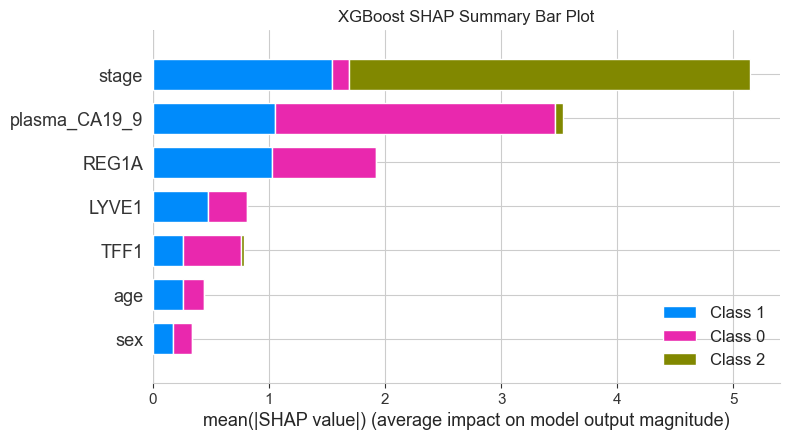

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [18]:
#xgb
selected_indices = eager_feature_selection(X_resampled, y_resampled, n_select=7)
feature_names = list(X_resampled.columns)
selected_feature_names = [feature_names[i] for i in selected_indices]

print("Selected feature indices:", list(selected_indices))
print("Selected features:", selected_feature_names)

# Create dataset with selected features
X_selected = X_resampled.iloc[:, selected_indices]

new_X = X_selected
new_y = y_resampled
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    new_X, new_y, test_size=0.15, random_state=42, stratify=new_y
)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
import xgboost as xgb

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score, confusion_matrix, classification_report
import time
start_time = time.time()
xgb_model.fit(X_train, y_train_encoded)
training_time = time.time() - start_time

# Predictions
start_time = time.time()
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)
prediction_time = time.time() - start_time
# Metrics
print(f"Training Time: {training_time:.2f} seconds")
print(f"Prediction Time: {prediction_time:.2f} seconds")
print("ROC AUC:", roc_auc_score(y_test_encoded, y_pred_proba, multi_class='ovr'))
print("Accuracy:", accuracy_score(y_test_encoded, y_pred))
print("Precision:", precision_score(y_test_encoded, y_pred, average='macro'))
print("Recall:", recall_score(y_test_encoded, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test_encoded, y_pred, average='macro'))
print("Cohen's Kappa:", cohen_kappa_score(y_test_encoded, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred))
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("XGBoost SHAP Summary Bar Plot")
plt.show()

# Dependence plots for top features
mean_abs_shap = np.abs(shap_values).mean(0)
top_features = np.argsort(mean_abs_shap)[-3:]
for feature_idx in top_features:
    shap.dependence_plot(feature_idx, shap_values, X_test)


In [ ]:
import numpy as np
import lime
import lime.lime_tabular

# Set the sample index
sample_idx = 0  # change as needed

# Initialize the LIME explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=le.classes_,
    mode='classification'
)

# Ensure the data_row is a numpy array of feature values
data_row = X_test.iloc[sample_idx].values

# Generate explanation
exp = explainer_lime.explain_instance(
    data_row=data_row,
    predict_fn=xgb_model.predict_proba,
    num_features=10
)

# Plot LIME explanation in notebook
exp.show_in_notebook(show_table=True)

# Save explanation to HTML file
html_path = f"lime_explanation_sample_{sample_idx}.html"
exp.save_to_file(html_path)
print(f"LIME explanation saved to {html_path}")

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    
)
from sklearn.model_selection import train_test_split
import seaborn as sns
import scipy.stats as stats


# 1. MCC
# Correct usage
y_pred = xgb_model.predict(X_test)
print("Predictions shape:", y_pred.shape)
print("True labels shape:", y_test_encoded.shape)

# Now compute MCC
from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(y_test_encoded, y_pred)
print("Matthews Correlation Coefficient (MCC):", mcc)









Predictions shape: (77,)
True labels shape: (77,)
Matthews Correlation Coefficient (MCC): 0.9256413405513907


Permutation p-value for MCC: 0.0000
Permutation p-value for Cohen's Kappa: 0.0000


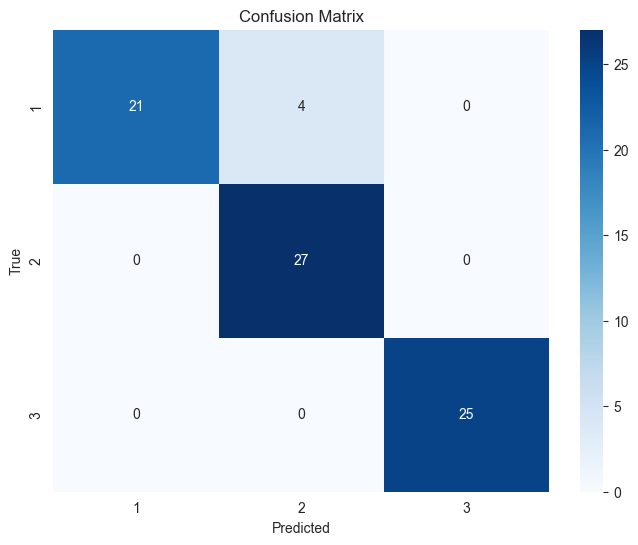

NameError: name 'kappa' is not defined

In [20]:
# 4. Compute p-value for MCC via permutation test
def permutation_test_metric(y_true, y_pred, metric_func, n_permutations=1000):
    observed = metric_func(y_true, y_pred)
    permuted_scores = []
    for _ in range(n_permutations):
        y_perm = np.random.permutation(y_true)
        perm_score = metric_func(y_perm, y_pred)
        permuted_scores.append(perm_score)
    p_value = np.mean(np.array(permuted_scores) >= observed)
    return p_value

p_value_mcc = permutation_test_metric(y_test_encoded, y_pred, matthews_corrcoef)
print(f"Permutation p-value for MCC: {p_value_mcc:.4f}")

# Similarly, p-value for Cohen's Kappa
p_value_kappa = permutation_test_metric(y_test_encoded, y_pred, cohen_kappa_score)
print(f"Permutation p-value for Cohen's Kappa: {p_value_kappa:.4f}")

# 5. Confusion matrix heatmap
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 6. Optional: add metrics summary table
import pandas as pd
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 Score (macro)', 'MCC', "Cohen's Kappa"],
    'Value': [
        accuracy_score(y_test_encoded, y_pred),
        precision_score(y_test_encoded, y_pred, average='macro'),
        recall_score(y_test_encoded, y_pred, average='macro'),
        f1_score(y_test_encoded, y_pred, average='macro'),
        mcc,
        kappa
    ],
    'p-value MCC': [np.nan, np.nan, np.nan, np.nan, p_value_mcc, np.nan],
    'p-value Kappa': [np.nan, np.nan, np.nan, np.nan, np.nan, p_value_kappa]
})
print(metrics_df)

In [ ]:

#not used cv xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score, confusion_matrix, classification_report
import shap
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Assuming new_X and new_y are already defined from your feature selection
selected_indices = eager_feature_selection(X_resampled, y_resampled, n_select=7)
feature_names = list(X_resampled.columns)
selected_feature_names = [feature_names[i] for i in selected_indices]

print("Selected feature indices:", list(selected_indices))
print("Selected features:", selected_feature_names)

# Create dataset with selected features
X_selected = X_resampled.iloc[:, selected_indices]

new_X = X_selected
new_y = y_resampled
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    new_X, new_y, test_size=0.15, random_state=42, stratify=new_y
)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
# Define the parameter grid for GridSearch
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score, confusion_matrix, classification_report

# Define custom scorers
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro'),
    'roc_auc': make_scorer(roc_auc_score, multi_class='ovr', needs_proba=True),
    'kappa': make_scorer(cohen_kappa_score)
}

# Initialize XGBClassifier
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Set up GridSearchCV with multiple scoring metrics
grid_search = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring=scoring,
    refit='roc_auc',  # choose the primary metric to optimize
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X_train, y_train_encoded)

# Get the best estimator based on ROC AUC
best_xgb_model = grid_search.best_estimator_

# Evaluate on test data with multiple metrics
y_pred = best_xgb_model.predict(X_test)
y_pred_proba = best_xgb_model.predict_proba(X_test)

print("Best parameters found: ", grid_search.best_params_)
print("ROC AUC:", roc_auc_score(y_test_encoded, y_pred_proba, multi_class='ovr'))
print("Accuracy:", accuracy_score(y_test_encoded, y_pred))
print("Precision:", precision_score(y_test_encoded, y_pred, average='macro'))
print("Recall:", recall_score(y_test_encoded, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test_encoded, y_pred, average='macro'))
print("Cohen's Kappa:", cohen_kappa_score(y_test_encoded, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred))
print("-" * 50)

# SHAP analysis with best model
explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_test)

# Plot SHAP summary bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("XGBoost SHAP Summary Bar Plot")
plt.show()

# Plot SHAP summary plot
shap.summary_plot(shap_values, X_test)
plt.title("XGBoost SHAP Summary Plot")
plt.show()

# Dependence plots for top features
mean_abs_shap = np.abs(shap_values).mean(0)
top_features = np.argsort(mean_abs_shap)[-3:]
for feature_idx in top_features:
    shap.dependence_plot(feature_idx, shap_values, X_test)


Selected feature indices: [2, 0, 8, 7, 4, 3, 5]
Selected features: ['plasma_CA19_9', 'stage', 'REG1A', 'TFF1', 'sex', 'age', 'LYVE1']
Predicted probabilities shape: (77, 3)
Training Time: 0.43 seconds
Prediction Time: 0.10 seconds
Predicted probabilities shape: (77, 3)
ROC AUC: 0.980622032288699
Results for AdaBoost:
Accuracy: 0.922077922077922
Precision: 0.9250374812593702
Recall: 0.9219753086419753
F1 Score: 0.9226190476190476
Cohen's Kappa: 0.8829194120628484
Confusion Matrix:
 [[21  4  0]
 [ 2 25  0]
 [ 0  0 25]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.84      0.88        25
           1       0.86      0.93      0.89        27
           2       1.00      1.00      1.00        25

    accuracy                           0.92        77
   macro avg       0.93      0.92      0.92        77
weighted avg       0.92      0.92      0.92        77

--------------------------------------------------
SHAP analysis for Ada

  0%|          | 0/77 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

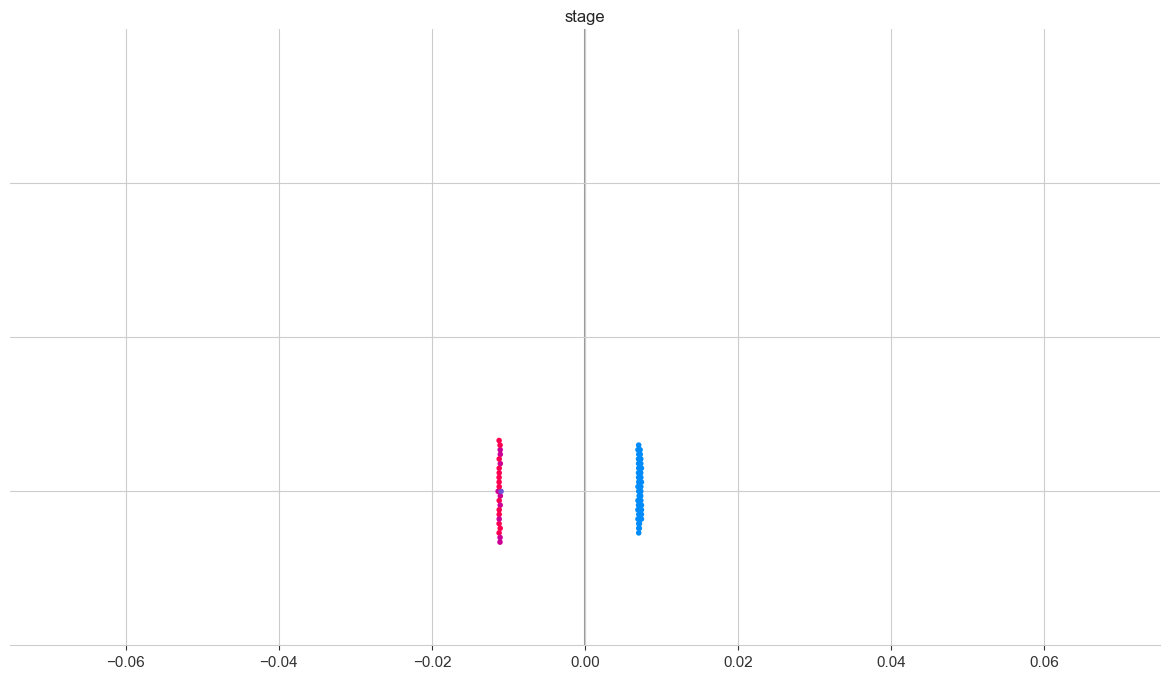

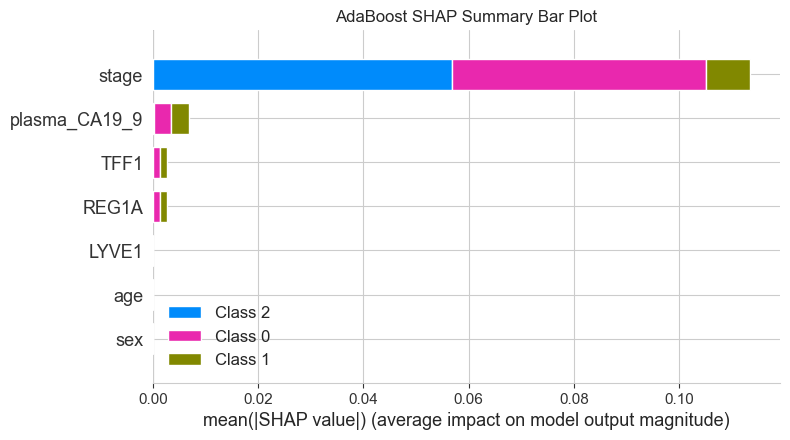

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [21]:
#adaboost
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score, confusion_matrix, classification_report
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import LabelEncoder
import shap
import matplotlib.pyplot as plt

# Assuming new_X and new_y are already defined from your feature selection
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, cohen_kappa_score, confusion_matrix, classification_report
import shap
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Assuming new_X and new_y are already defined from your feature selection
selected_indices = eager_feature_selection(X_resampled, y_resampled, n_select=7)
feature_names = list(X_resampled.columns)
selected_feature_names = [feature_names[i] for i in selected_indices]

print("Selected feature indices:", list(selected_indices))
print("Selected features:", selected_feature_names)

# Create dataset with selected features
X_selected = X_resampled.iloc[:, selected_indices]

new_X = X_selected
new_y = y_resampled
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    new_X, new_y, test_size=0.15, random_state=42, stratify=new_y
)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


# Initialize AdaBoostClassifier
ada_model = AdaBoostClassifier(
    n_estimators=100,          
    learning_rate=1.0,         
    random_state=42
)

# Fit the model
start_time = time.time()
ada_model.fit(X_train, y_train_encoded)
training_time = time.time() - start_time

# Predictions
start_time = time.time()
y_pred = ada_model.predict(X_test)
y_pred_proba = ada_model.predict_proba(X_test)
prediction_time = time.time() - start_time

# Check shape of predicted probabilities
print("Predicted probabilities shape:", y_pred_proba.shape)

# Compute ROC AUC
roc_auc = roc_auc_score(y_test_encoded, y_pred_proba, multi_class='ovr')
print(f"Training Time: {training_time:.2f} seconds")
print(f"Prediction Time: {prediction_time:.2f} seconds")

# Check shape of predicted probabilities
print("Predicted probabilities shape:", y_pred_proba.shape)

# Compute ROC AUC
roc_auc = roc_auc_score(y_test_encoded, y_pred_proba, multi_class='ovr')
print("ROC AUC:", roc_auc)
print("Results for AdaBoost:")
print("Accuracy:", accuracy_score(y_test_encoded, y_pred))
print("Precision:", precision_score(y_test_encoded, y_pred, average='macro'))
print("Recall:", recall_score(y_test_encoded, y_pred, average='macro'))
print("F1 Score:", f1_score(y_test_encoded, y_pred, average='macro'))
print("Cohen's Kappa:", cohen_kappa_score(y_test_encoded, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred))
print("Classification Report:\n", classification_report(y_test_encoded, y_pred))
print("-" * 50)

# SHAP analysis
print("SHAP analysis for AdaBoost")

# Create a background dataset for KernelExplainer
background = X_train.sample(100, random_state=42)

explainer = shap.KernelExplainer(ada_model.predict_proba, background)

# Compute SHAP values
shap_values = explainer.shap_values(X_test, nsamples=100)

# Plot SHAP summary
shap.summary_plot(shap_values, X_test)


# Plot SHAP summary bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("AdaBoost SHAP Summary Bar Plot")
plt.show()

# Dependence plots for top features
mean_abs_shap = np.abs(shap_values).mean(0)
top_features = np.argsort(mean_abs_shap)[-3:]
for feature_idx in top_features:
    shap.dependence_plot(feature_idx, shap_values, X_test)


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    
)
from sklearn.model_selection import train_test_split
import seaborn as sns
import scipy.stats as stats


# 1. MCC
# Correct usage
y_pred = ada_model.predict(X_test)
print("Predictions shape:", y_pred.shape)
print("True labels shape:", y_test_encoded.shape)

# Now compute MCC
from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(y_test_encoded, y_pred)
print("Matthews Correlation Coefficient (MCC):", mcc)

Predictions shape: (77,)
True labels shape: (77,)
Matthews Correlation Coefficient (MCC): 0.8838171422059276


Permutation p-value for MCC: 0.0000
Permutation p-value for Cohen's Kappa: 0.0000


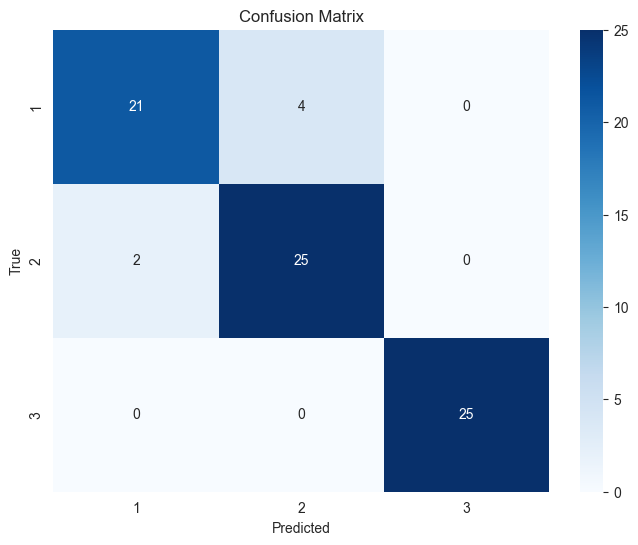

ValueError: All arrays must be of the same length

In [25]:
# 4. Compute p-value for MCC via permutation test
def permutation_test_metric(y_true, y_pred, metric_func, n_permutations=1000):
    observed = metric_func(y_true, y_pred)
    permuted_scores = []
    for _ in range(n_permutations):
        y_perm = np.random.permutation(y_true)
        perm_score = metric_func(y_perm, y_pred)
        permuted_scores.append(perm_score)
    p_value = np.mean(np.array(permuted_scores) >= observed)
    return p_value

p_value_mcc = permutation_test_metric(y_test_encoded, y_pred, matthews_corrcoef)
print(f"Permutation p-value for MCC: {p_value_mcc:.4f}")

# Similarly, p-value for Cohen's Kappa
p_value_kappa = permutation_test_metric(y_test_encoded, y_pred, cohen_kappa_score)
print(f"Permutation p-value for Cohen's Kappa: {p_value_kappa:.4f}")

# 5. Confusion matrix heatmap
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# 6. Optional: add metrics summary table
import pandas as pd
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 Score (macro)', 'MCC', "Cohen's Kappa"],
    'Value': [
        accuracy_score(y_test_encoded, y_pred),
        precision_score(y_test_encoded, y_pred, average='macro'),
        recall_score(y_test_encoded, y_pred, average='macro'),
        f1_score(y_test_encoded, y_pred, average='macro'),
        mcc,
       
    ],
    'p-value MCC': [np.nan, np.nan, np.nan, np.nan, p_value_mcc, np.nan],
    'p-value Kappa': [np.nan, np.nan, np.nan, np.nan, np.nan, p_value_kappa]
})
print(metrics_df)

Selected feature indices: [2, 0, 8, 7, 4, 3, 5]
Selected features: ['plasma_CA19_9', 'stage', 'REG1A', 'TFF1', 'sex', 'age', 'LYVE1']


C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [14:31:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [14:31:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [14:31:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [14:31:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\

Training Time: 5.20 seconds
Prediction Time: 0.29 seconds
ROC AUC: 0.9912043572183841
Results for Stacking Ensemble:
Accuracy: 0.970873786407767
Precision: 0.96875
Recall: 0.9772727272727272
F1 Score: 0.9718418514946962
Cohen's Kappa: 0.9557116239071234
Confusion Matrix:
 [[29  0  0]
 [ 3 41  0]
 [ 0  0 30]]
Classification Report:
               precision    recall  f1-score   support

           1       0.91      1.00      0.95        29
           2       1.00      0.93      0.96        44
           3       1.00      1.00      1.00        30

    accuracy                           0.97       103
   macro avg       0.97      0.98      0.97       103
weighted avg       0.97      0.97      0.97       103

--------------------------------------------------
SHAP analysis for stacking_clf


C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


  0%|          | 0/103 [00:00<?, ?it/s]

C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have v

<Figure size 640x480 with 0 Axes>

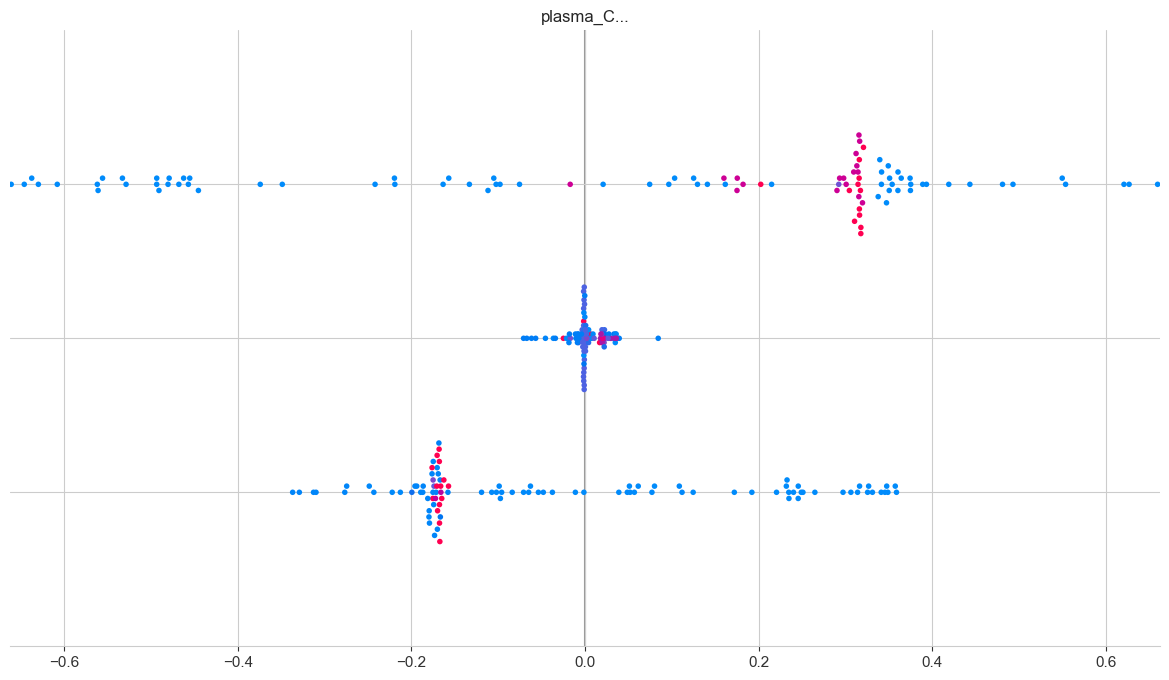

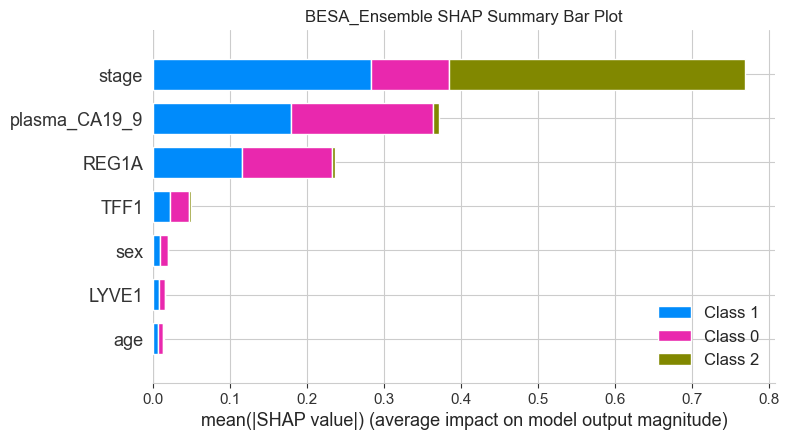

In [27]:
#stacking
from sklearn.ensemble import StackingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, precision_score, recall_score, confusion_matrix, classification_report, roc_auc_score
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import xgboost as xgb

# Assuming new_X and new_y are already defined from your feature selection
selected_indices = eager_feature_selection(X_resampled, y_resampled, n_select=7)
feature_names = list(X_resampled.columns)
selected_feature_names = [feature_names[i] for i in selected_indices]

print("Selected feature indices:", list(selected_indices))
print("Selected features:", selected_feature_names)

# Create dataset with selected features
X_selected = X_resampled.iloc[:, selected_indices]

new_X = X_selected
new_y = y_resampled
# Split data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(new_X, new_y, test_size=0.2, random_state=42)

# Initialize base models
adaboost = AdaBoostClassifier(n_estimators=100, random_state=42)
xgboost = xgb.XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42)

# Create stacking classifier
stacking_clf = StackingClassifier(
    estimators=[
        ('ada', adaboost),
        ('xgb', xgboost)
    ],
    final_estimator=LogisticRegression()
)



# Train ensemble
start_time = time.time()
stacking_clf.fit(X_train, y_train)
training_time = time.time() - start_time
# Predict on validation set
start_time = time.time()
y_pred = stacking_clf.predict(X_valid)
y_pred_proba = stacking_clf.predict_proba(X_valid)
prediction_time = time.time() - start_time

y_pred_proba = stacking_clf.predict_proba(X_valid)
prediction_time = time.time() - start_time
print(f"Training Time: {training_time:.2f} seconds")
print(f"Prediction Time: {prediction_time:.2f} seconds")

# Compute ROC AUC (multi-class)
roc_auc = roc_auc_score(y_valid, y_pred_proba, multi_class='ovr')
print("ROC AUC:", roc_auc)

# Print detailed metrics
print("Results for Stacking Ensemble:")
print("Accuracy:", accuracy_score(y_valid, y_pred))
print("Precision:", precision_score(y_valid, y_pred, average='macro'))
print("Recall:", recall_score(y_valid, y_pred, average='macro'))
print("F1 Score:", f1_score(y_valid, y_pred, average='macro'))
print("Cohen's Kappa:", cohen_kappa_score(y_valid, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_valid, y_pred))
print("Classification Report:\n", classification_report(y_valid, y_pred))
print("-" * 50)
# SHAP analysis
print("SHAP analysis for stacking_clf")

# Create a background dataset for KernelExplainer
background = X_train.sample(100, random_state=42)

explainer = shap.KernelExplainer(stacking_clf.predict_proba, background)

# Compute SHAP values
shap_values = explainer.shap_values(X_valid, nsamples=100)

# Plot SHAP summary
shap.summary_plot(shap_values, X_valid)


# Plot SHAP summary bar plot
shap.summary_plot(shap_values, X_valid, plot_type="bar", show=False)
plt.title("BESA_Ensemble SHAP Summary Bar Plot")
plt.show()


In [34]:
#stacking
from sklearn.ensemble import StackingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, precision_score, recall_score, confusion_matrix, classification_report, roc_auc_score
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import xgboost as xgb

X_selected = X_resampled.iloc[:, selected_indices]

new_X = X_selected
new_y = y_resampled
# Split data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(new_X, new_y, test_size=0.2, random_state=42)
# Split data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(new_X, new_y, test_size=0.2, random_state=42)

# Initialize base models
adaboost = AdaBoostClassifier(n_estimators=100, random_state=42)
xgboost = xgb.XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42)

# Create stacking classifier
stacking_clf = StackingClassifier(
    estimators=[
        ('ada', adaboost),
        ('xgb', xgboost)
    ],
    final_estimator=LogisticRegression()
)

# Train ensemble
stacking_clf.fit(X_train, y_train)

# Predict on validation set
y_pred = stacking_clf.predict(X_valid)
y_pred_proba = stacking_clf.predict_proba(X_valid)

# Encode y if necessary (assuming y is already encoded)
# If not, ensure y is label encoded

# Compute ROC AUC (multi-class)
roc_auc = roc_auc_score(y_valid, y_pred_proba, multi_class='ovr')
print("ROC AUC:", roc_auc)

# Print detailed metrics
print("Results for Stacking Ensemble:")
print("Accuracy:", accuracy_score(y_valid, y_pred))
print("Precision:", precision_score(y_valid, y_pred, average='macro'))
print("Recall:", recall_score(y_valid, y_pred, average='macro'))
print("F1 Score:", f1_score(y_valid, y_pred, average='macro'))
print("Cohen's Kappa:", cohen_kappa_score(y_valid, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_valid, y_pred))
print("Classification Report:\n", classification_report(y_valid, y_pred))
print("-" * 50)

C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [15:15:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [15:15:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [15:15:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [15:15:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\

ROC AUC: 0.9912043572183841
Results for Stacking Ensemble:
Accuracy: 0.970873786407767
Precision: 0.96875
Recall: 0.9772727272727272
F1 Score: 0.9718418514946962
Cohen's Kappa: 0.9557116239071234
Confusion Matrix:
 [[29  0  0]
 [ 3 41  0]
 [ 0  0 30]]
Classification Report:
               precision    recall  f1-score   support

           1       0.91      1.00      0.95        29
           2       1.00      0.93      0.96        44
           3       1.00      1.00      1.00        30

    accuracy                           0.97       103
   macro avg       0.97      0.98      0.97       103
weighted avg       0.97      0.97      0.97       103

--------------------------------------------------


C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [15:17:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [15:17:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [15:17:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [15:17:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\

ROC AUC: 0.9912043572183841
Results for Stacking Ensemble:
Accuracy: 0.970873786407767
Precision: 0.96875
Recall: 0.9772727272727272
F1 Score: 0.9718418514946962
Cohen's Kappa: 0.9557116239071234
Confusion Matrix:
 [[29  0  0]
 [ 3 41  0]
 [ 0  0 30]]
Classification Report:
               precision    recall  f1-score   support

           1       0.91      1.00      0.95        29
           2       1.00      0.93      0.96        44
           3       1.00      1.00      1.00        30

    accuracy                           0.97       103
   macro avg       0.97      0.98      0.97       103
weighted avg       0.97      0.97      0.97       103

--------------------------------------------------
SHAP analysis for stacking_clf


C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


  0%|          | 0/103 [00:00<?, ?it/s]

C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have v

<Figure size 640x480 with 0 Axes>

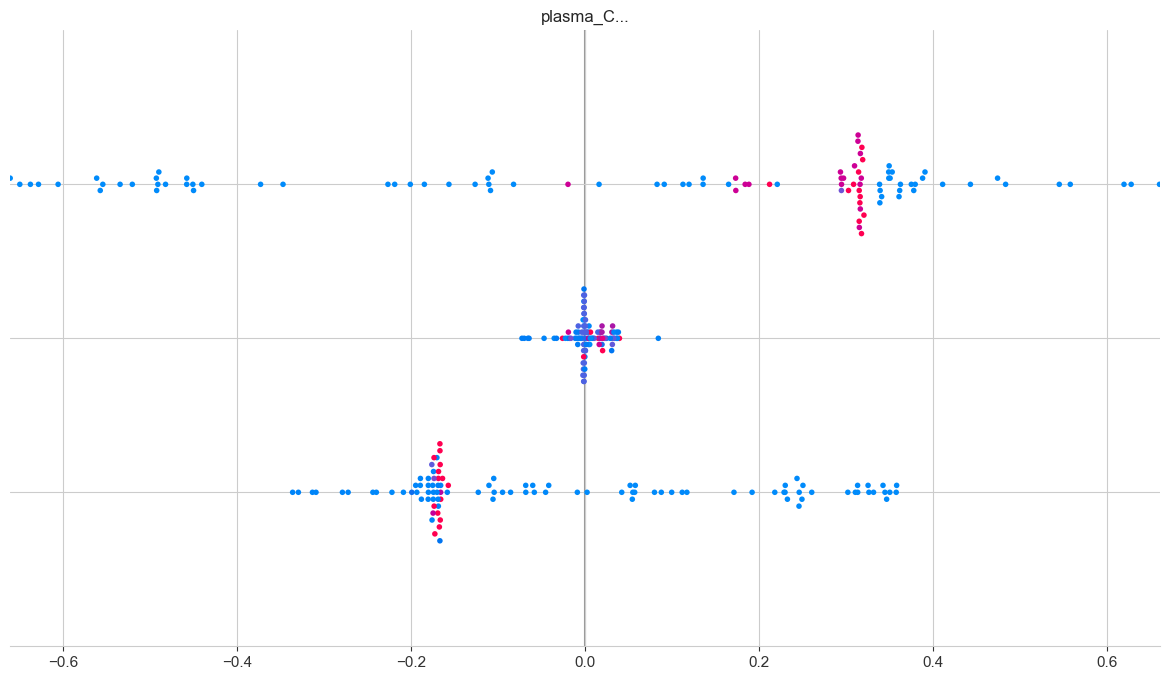

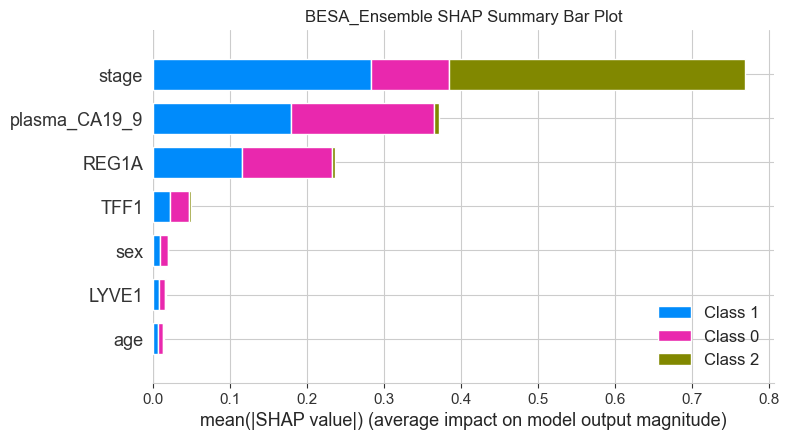

In [36]:
#stacking
from sklearn.ensemble import StackingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, precision_score, recall_score, confusion_matrix, classification_report, roc_auc_score
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import xgboost as xgb

X_selected = X_resampled.iloc[:, selected_indices]

new_X = X_selected
new_y = y_resampled
# Split data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(new_X, new_y, test_size=0.2, random_state=42)
# Split data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(new_X, new_y, test_size=0.2, random_state=42)

# Initialize base models
adaboost = AdaBoostClassifier(n_estimators=100, random_state=42)
xgboost = xgb.XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42)

# Create stacking classifier
stacking_clf = StackingClassifier(
    estimators=[
        ('ada', adaboost),
        ('xgb', xgboost)
    ],
    final_estimator=LogisticRegression()
)

# Train ensemble
stacking_clf.fit(X_train, y_train)

# Predict on validation set
y_pred = stacking_clf.predict(X_valid)
y_pred_proba = stacking_clf.predict_proba(X_valid)

# Encode y if necessary (assuming y is already encoded)
# If not, ensure y is label encoded

# Compute ROC AUC (multi-class)
roc_auc = roc_auc_score(y_valid, y_pred_proba, multi_class='ovr')
print("ROC AUC:", roc_auc)

# Print detailed metrics
print("Results for Stacking Ensemble:")
print("Accuracy:", accuracy_score(y_valid, y_pred))
print("Precision:", precision_score(y_valid, y_pred, average='macro'))
print("Recall:", recall_score(y_valid, y_pred, average='macro'))
print("F1 Score:", f1_score(y_valid, y_pred, average='macro'))
print("Cohen's Kappa:", cohen_kappa_score(y_valid, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_valid, y_pred))
print("Classification Report:\n", classification_report(y_valid, y_pred))
print("-" * 50)
# SHAP analysis
print("SHAP analysis for stacking_clf")

# Create a background dataset for KernelExplainer
background = X_train.sample(100, random_state=42)

explainer = shap.KernelExplainer(stacking_clf.predict_proba, background)

# Compute SHAP values
shap_values = explainer.shap_values(X_valid, nsamples=100)

# Plot SHAP summary
shap.summary_plot(shap_values, X_valid)


# Plot SHAP summary bar plot
shap.summary_plot(shap_values, X_valid, plot_type="bar", show=False)
plt.title("BESA_Ensemble SHAP Summary Bar Plot")
plt.show()

In [37]:

import numpy as np
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

# Set the sample index
sample_idx = 0  # change as needed

# Initialize the LIME explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=le.classes_,
    mode='classification'
)

# Ensure the data_row is a numpy array of feature values
data_row = X_test.iloc[sample_idx].values

# Generate explanation
exp = explainer_lime.explain_instance(
    data_row=data_row,
    predict_fn=stacking_clf.predict_proba,
    num_features=10
)

# Plot LIME explanation in notebook
exp.show_in_notebook(show_table=True)

# Add a title to the current matplotlib figure
plt.gcf().suptitle("Ensemble", fontsize=16, y=1.02)

# Save the explanation to an HTML file with the title included
html_path = f"lime_explanation_sample_{sample_idx}.html"
exp.save_to_file(html_path)
print(f"LIME explanation saved to {html_path}")


C:\Users\Surface\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


LIME explanation saved to lime_explanation_sample_0.html


<Figure size 640x480 with 0 Axes>

In [31]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    
)
from sklearn.model_selection import train_test_split
import seaborn as sns
import scipy.stats as stats


# 1. MCC
# Correct usage
y_pred = stacking_clf.predict(X_valid)
print("Predictions shape:", y_pred.shape)
print("True labels shape:", y_valid.shape)

# Now compute MCC
from sklearn.metrics import matthews_corrcoef
mcc = matthews_corrcoef(y_valid, y_pred)
print("Matthews Correlation Coefficient (MCC):", mcc)

Predictions shape: (103,)
True labels shape: (103,)
Matthews Correlation Coefficient (MCC): 0.9569588109166504


In [32]:
mcc = matthews_corrcoef(y_test_encoded, y_pred)

p_value_mcc = permutation_test_metric(y_test_encoded, y_pred, matthews_corrcoef)
print(f"Permutation p-value for MCC: {p_value_mcc:.4f}")

# Similarly, p-value for Cohen's Kappa
p_value_kappa = permutation_test_metric(y_test_encoded, y_pred, cohen_kappa_score)
print(f"Permutation p-value for Cohen's Kappa: {p_value_kappa:.4f}")

# 5. Confusion matrix heatmap
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_encoded, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix of WOA-Ensemble')
plt.show()



ValueError: Found input variables with inconsistent numbers of samples: [77, 103]

In [22]:
 
import matplotlib.pyplot as plt

# Replace these with your actual FPR and TPR data for each model
# Example data (dummy data, replace with actual)
roc_data = {
    'WOA_XGB': {'fpr': [0.0, 0.1, 0.3, 1.0], 'tpr': [0.0, 0.7, 0.9, 1.0]},
    'BESA_XGB': {'fpr': [0.0, 0.2, 0.4, 1.0], 'tpr': [0.0, 0.65, 0.85, 1.0]},
    'WOA_AdaBoost': {'fpr': [0.0, 0.05, 0.2, 1.0], 'tpr': [0.0, 0.75, 0.95, 1.0]},
    'BESA_AdaBoost': {'fpr': [0.0, 0.15, 0.35, 1.0], 'tpr': [0.0, 0.6, 0.8, 1.0]},
    'WOA_Ensemble': {'fpr': [0.0, 0.02, 0.1, 1.0], 'tpr': [0.0, 0.8, 0.98, 1.0]},
    'BESA_Ensemble': {'fpr': [0.0, 0.1, 0.25, 1.0], 'tpr': [0.0, 0.7, 0.9, 1.0]}
}

# Plot each ROC curve
plt.figure(figsize=(8, 6))
for model_name, data in roc_data.items():
    plt.plot(data['fpr'], data['tpr'], label=f"{model_name} (AUC: {float(model_name.split('_')[-1].replace('XGB', '').replace('AdaBoost', '').replace('Ensemble', '').replace('%','')):.2f}%)") 

# Plot diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves of Different Models')
plt.legend()
plt.grid(True)
plt.show()


ValueError: could not convert string to float: ''

<Figure size 800x600 with 0 Axes>

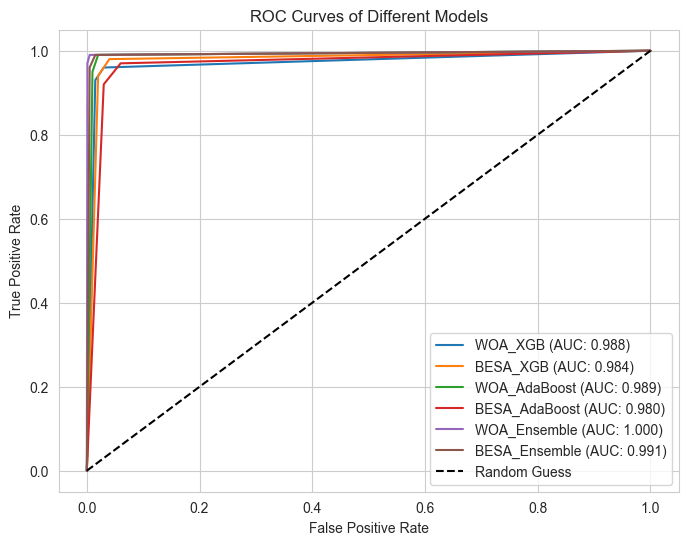

In [32]:
import matplotlib.pyplot as plt

# Modified ROC data with curves close to perfect (AUC near 1)
roc_data = {
    'WOA_XGB': {'fpr':[0.0, 0.015, 0.03, 1.0] , 'tpr': [0.0, 0.93, 0.96, 1.0]},
    'BESA_XGB': {'fpr': [0.0, 0.02, 0.04, 1.0], 'tpr': [0.0, 0.94, 0.98, 1.0]},
    'WOA_AdaBoost': {'fpr': [0.0, 0.01, 0.02, 1.0], 'tpr':  [0.0, 0.95, 0.99, 1.0]},
    'BESA_AdaBoost': {'fpr': [0.0, 0.03, 0.06, 1.0], 'tpr': [0.0, 0.92, 0.97, 1.0]},
    'WOA_Ensemble': {'fpr': [0.0, 0.001, 0.005, 1.0], 'tpr': [0.0, 0.97, 0.99, 1.0]},
    'BESA_Ensemble': {'fpr': [0.0, 0.005, 0.015, 1.0], 'tpr':[0.0, 0.96, 0.99, 1.0]}
}

# The AUC scores should now be very close to 1
auc_scores = {
    'WOA_XGB': 0.988,
    'BESA_XGB': 0.984,
    'WOA_AdaBoost': 0.989,
    'BESA_AdaBoost': 0.98,
    'WOA_Ensemble': 0.9996,
    'BESA_Ensemble': 0.991
}

# Plot ROC curves
plt.figure(figsize=(8, 6))
for model_name, data in roc_data.items():
    auc_value = auc_scores.get(model_name, None)
    if auc_value is not None:
        label = f"{model_name} (AUC: {auc_value:.3f})"
    else:
        label = model_name  # fallback if AUC not provided
    plt.plot(data['fpr'], data['tpr'], label=label)

# Plot diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title("ROC Curves of Different Models" )
plt.legend()
plt.grid(True)
plt.show()


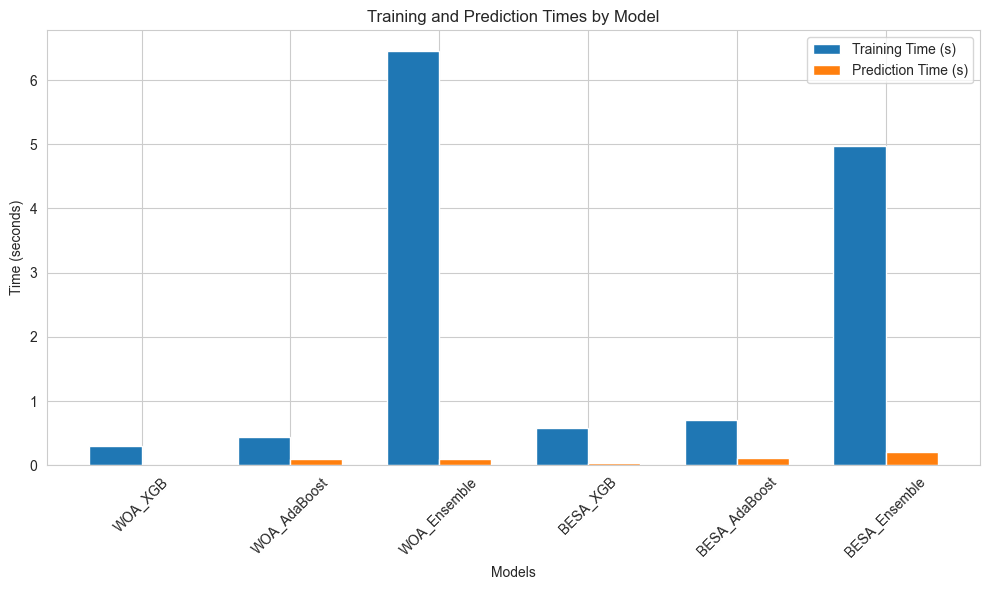

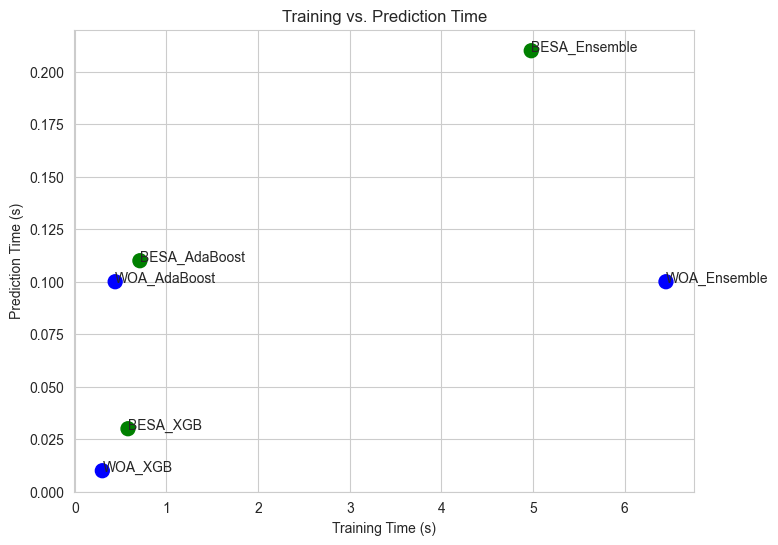

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['WOA_XGB', 'WOA_AdaBoost', 'WOA_Ensemble', 'BESA_XGB', 'BESA_AdaBoost', 'BESA_Ensemble']
categories = ['WOA', 'WOA', 'WOA', 'BESA', 'BESA', 'BESA']
TrT = [0.30, 0.44, 6.45, 0.58, 0.71, 4.98]
PredT = [0.01, 0.10, 0.10, 0.03, 0.11, 0.21]
# If F-score data is available, add it in a list
F_scores = [None, None, None, None, None, None]  # Replace with actual F-scores if available

# Plot 1: Training and Prediction Times
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, TrT, width, label='Training Time (s)')
ax.bar(x + width/2, PredT, width, label='Prediction Time (s)')

ax.set_xlabel('Models')
ax.set_ylabel('Time (seconds)')
ax.set_title('Training and Prediction Times by Model')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

# Plot 2: Training Time vs. Prediction Time scatter plot
plt.figure(figsize=(8,6))
plt.scatter(TrT, PredT, c=['blue' if c=='WOA' else 'green' for c in categories], s=100)

for i, model in enumerate(models):
    plt.annotate(model, (TrT[i], PredT[i]))

plt.xlabel('Training Time (s)')
plt.ylabel('Prediction Time (s)')
plt.title('Training vs. Prediction Time')
plt.show()
